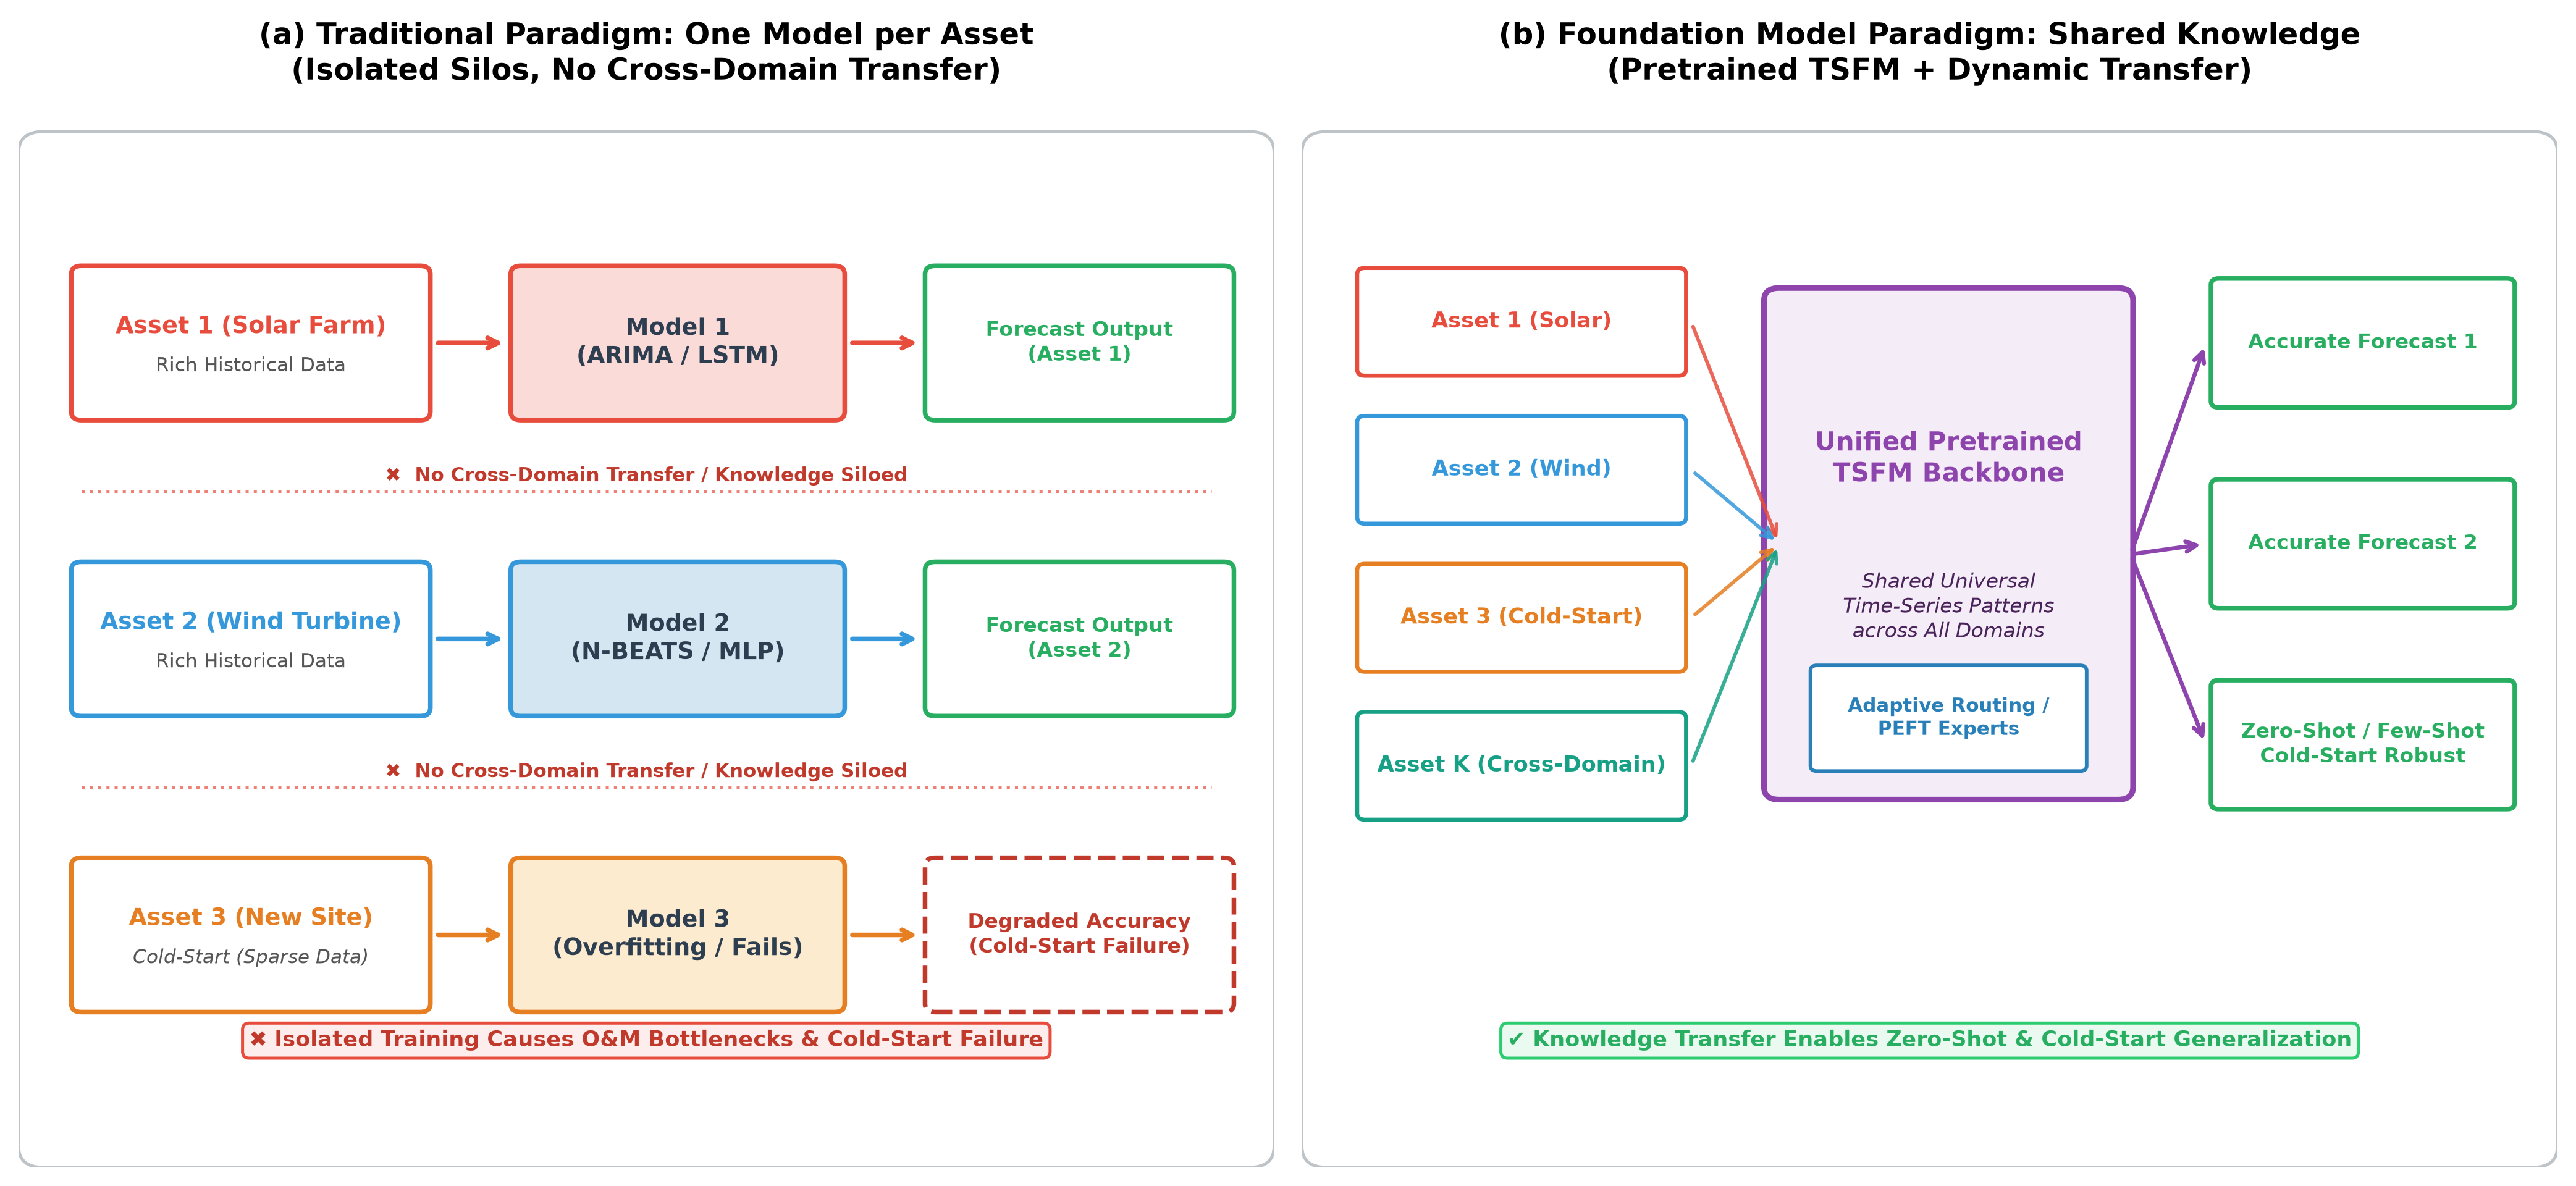

In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

# 스타일 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), dpi=300)

# 색상 팔레트
c_asset1, c_asset2, c_asset3 = '#e74c3c', '#3498db', '#e67e22'
c_m1_bg, c_m2_bg, c_m3_bg = '#fadbd8', '#d4e6f1', '#fdebd0'
c_tsfm, c_tsfm_bg = '#8e44ad', '#f4ecf7'

# -------------------------------------------------------------------------
# Subplot 1: Traditional Paradigm (One Model per Asset)
# -------------------------------------------------------------------------
ax1.set_title(
    '(a) Traditional Paradigm: One Model per Asset\n(Isolated Silos, No'
    ' Cross-Domain Transfer)',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')

# 테두리 박스
ax1.add_patch(
    patches.FancyBboxPatch(
        (0.2, 0.2),
        9.6,
        9.4,
        boxstyle='round,pad=0.2',
        fc='#ffffff',
        ec='#bdc3c7',
        lw=1.2,
    )
)

assets_data = [
    (
        'Asset 1 (Solar Farm)',
        'Rich Historical Data',
        c_asset1,
        c_m1_bg,
        'Model 1\n(ARIMA / LSTM)',
        7.8,
        False,
    ),
    (
        'Asset 2 (Wind Turbine)',
        'Rich Historical Data',
        c_asset2,
        c_m2_bg,
        'Model 2\n(N-BEATS / MLP)',
        5.0,
        False,
    ),
    (
        'Asset 3 (New Site)',
        'Cold-Start (Sparse Data)',
        c_asset3,
        c_m3_bg,
        'Model 3\n(Overfitting / Fails)',
        2.2,
        True,
    ),
]

for name, desc, stroke, fill, model_lbl, y, is_cold in assets_data:
  # Data Box
  ax1.add_patch(
      patches.FancyBboxPatch(
          (0.5, y - 0.65),
          2.7,
          1.3,
          boxstyle='round,pad=0.08',
          fc='#ffffff',
          ec=stroke,
          lw=1.8,
      )
  )
  ax1.text(
      1.85,
      y + 0.15,
      name,
      ha='center',
      va='center',
      fontsize=9,
      fontweight='bold',
      color=stroke,
  )
  ax1.text(
      1.85,
      y - 0.22,
      desc,
      ha='center',
      va='center',
      fontsize=7.5,
      color='#555555',
      fontstyle='italic' if is_cold else 'normal',
  )

  # Arrow 1
  ax1.annotate(
      '',
      xy=(3.9, y),
      xytext=(3.3, y),
      arrowprops=dict(arrowstyle='->', color=stroke, lw=1.8),
  )

  # Model Box
  ax1.add_patch(
      patches.FancyBboxPatch(
          (4.0, y - 0.65),
          2.5,
          1.3,
          boxstyle='round,pad=0.08',
          fc=fill,
          ec=stroke,
          lw=1.8,
      )
  )
  ax1.text(
      5.25,
      y,
      model_lbl,
      ha='center',
      va='center',
      fontsize=9,
      fontweight='bold',
      color='#2c3e50',
  )

  # Arrow 2
  ax1.annotate(
      '',
      xy=(7.2, y),
      xytext=(6.6, y),
      arrowprops=dict(arrowstyle='->', color=stroke, lw=1.8),
  )

  # Output Box
  out_txt = (
      'Degraded Accuracy\n(Cold-Start Failure)'
      if is_cold
      else f"Forecast Output\n({name.split()[0]} {name.split()[1]})"
  )
  out_col = '#c0392b' if is_cold else '#27ae60'
  ax1.add_patch(
      patches.FancyBboxPatch(
          (7.3, y - 0.65),
          2.3,
          1.3,
          boxstyle='round,pad=0.08',
          fc='#ffffff',
          ec=out_col,
          lw=1.8,
          ls='--' if is_cold else '-',
      )
  )
  ax1.text(
      8.45,
      y,
      out_txt,
      ha='center',
      va='center',
      fontsize=8,
      fontweight='bold',
      color=out_col,
  )

# 격리 장벽 (Barrier Line)
for y_line in [6.4, 3.6]:
  ax1.plot(
      [0.5, 9.5],
      [y_line, y_line],
      color='#e74c3c',
      linestyle=':',
      lw=1.2,
      alpha=0.7,
  )
  ax1.text(
      5.0,
      y_line + 0.14,
      '✖  No Cross-Domain Transfer / Knowledge Siloed',
      ha='center',
      va='center',
      fontsize=7.5,
      color='#c0392b',
      fontweight='bold',
  )

# -------------------------------------------------------------------------
# Subplot 2: Foundation Model Paradigm (Cross-Domain Transfer)
# -------------------------------------------------------------------------
ax2.set_title(
    '(b) Foundation Model Paradigm: Shared Knowledge\n(Pretrained TSFM +'
    ' Dynamic Transfer)',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')

ax2.add_patch(
    patches.FancyBboxPatch(
        (0.2, 0.2),
        9.6,
        9.4,
        boxstyle='round,pad=0.2',
        fc='#ffffff',
        ec='#bdc3c7',
        lw=1.2,
    )
)

multi_inputs = [
    ('Asset 1 (Solar)', 8.0, c_asset1),
    ('Asset 2 (Wind)', 6.6, c_asset2),
    ('Asset 3 (Cold-Start)', 5.2, c_asset3),
    ('Asset K (Cross-Domain)', 3.8, '#16a085'),
]

for name, y, stroke in multi_inputs:
  ax2.add_patch(
      patches.FancyBboxPatch(
          (0.5, y - 0.45),
          2.5,
          0.9,
          boxstyle='round,pad=0.06',
          fc='#ffffff',
          ec=stroke,
          lw=1.6,
      )
  )
  ax2.text(
      1.75,
      y,
      name,
      ha='center',
      va='center',
      fontsize=8.5,
      fontweight='bold',
      color=stroke,
  )
  ax2.annotate(
      '',
      xy=(3.8, 5.9),
      xytext=(3.1, y),
      arrowprops=dict(arrowstyle='->', color=stroke, lw=1.4, alpha=0.85),
  )

# TSFM Backbone Box
ax2.add_patch(
    patches.FancyBboxPatch(
        (3.8, 3.6),
        2.7,
        4.6,
        boxstyle='round,pad=0.12',
        fc=c_tsfm_bg,
        ec=c_tsfm,
        lw=2.2,
    )
)
ax2.text(
    5.15,
    6.7,
    'Unified Pretrained\nTSFM Backbone',
    ha='center',
    va='center',
    fontsize=10,
    fontweight='bold',
    color=c_tsfm,
)
ax2.text(
    5.15,
    5.3,
    'Shared Universal\nTime-Series Patterns\nacross All Domains',
    ha='center',
    va='center',
    fontsize=8,
    color='#4a235a',
    style='italic',
)

# Adapter Box
ax2.add_patch(
    patches.FancyBboxPatch(
        (4.1, 3.8),
        2.1,
        0.9,
        boxstyle='round,pad=0.05',
        fc='#ffffff',
        ec='#2980b9',
        lw=1.4,
    )
)
ax2.text(
    5.15,
    4.25,
    'Adaptive Routing /\nPEFT Experts',
    ha='center',
    va='center',
    fontsize=7.5,
    fontweight='bold',
    color='#2980b9',
)

# Output Arrows & Boxes
fm_outputs = [
    ('Accurate Forecast 1', 7.8, '#27ae60'),
    ('Accurate Forecast 2', 5.9, '#27ae60'),
    ('Zero-Shot / Few-Shot\nCold-Start Robust', 4.0, '#27ae60'),
]

for out_lbl, y, stroke in fm_outputs:
  ax2.annotate(
      '',
      xy=(7.2, y),
      xytext=(6.6, 5.8),
      arrowprops=dict(arrowstyle='->', color=c_tsfm, lw=1.6),
  )
  ax2.add_patch(
      patches.FancyBboxPatch(
          (7.3, y - 0.55),
          2.3,
          1.1,
          boxstyle='round,pad=0.06',
          fc='#ffffff',
          ec=stroke,
          lw=1.8,
      )
  )
  ax2.text(
      8.45,
      y,
      out_lbl,
      ha='center',
      va='center',
      fontsize=8,
      fontweight='bold',
      color=stroke,
  )

# 하단 메시지 배지
ax1.text(
    5.0,
    1.2,
    '✖ Isolated Training Causes O&M Bottlenecks & Cold-Start Failure',
    ha='center',
    va='center',
    fontsize=8.5,
    fontweight='bold',
    color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fdedec', ec='#e74c3c', lw=1.2),
)

ax2.text(
    5.0,
    1.2,
    '✔ Knowledge Transfer Enables Zero-Shot & Cold-Start Generalization',
    ha='center',
    va='center',
    fontsize=8.5,
    fontweight='bold',
    color='#27ae60',
    bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#2ecc71', lw=1.2),
)

plt.tight_layout()
plt.savefig('one_model_per_asset_figure.png', dpi=300, bbox_inches='tight')
plt.show()

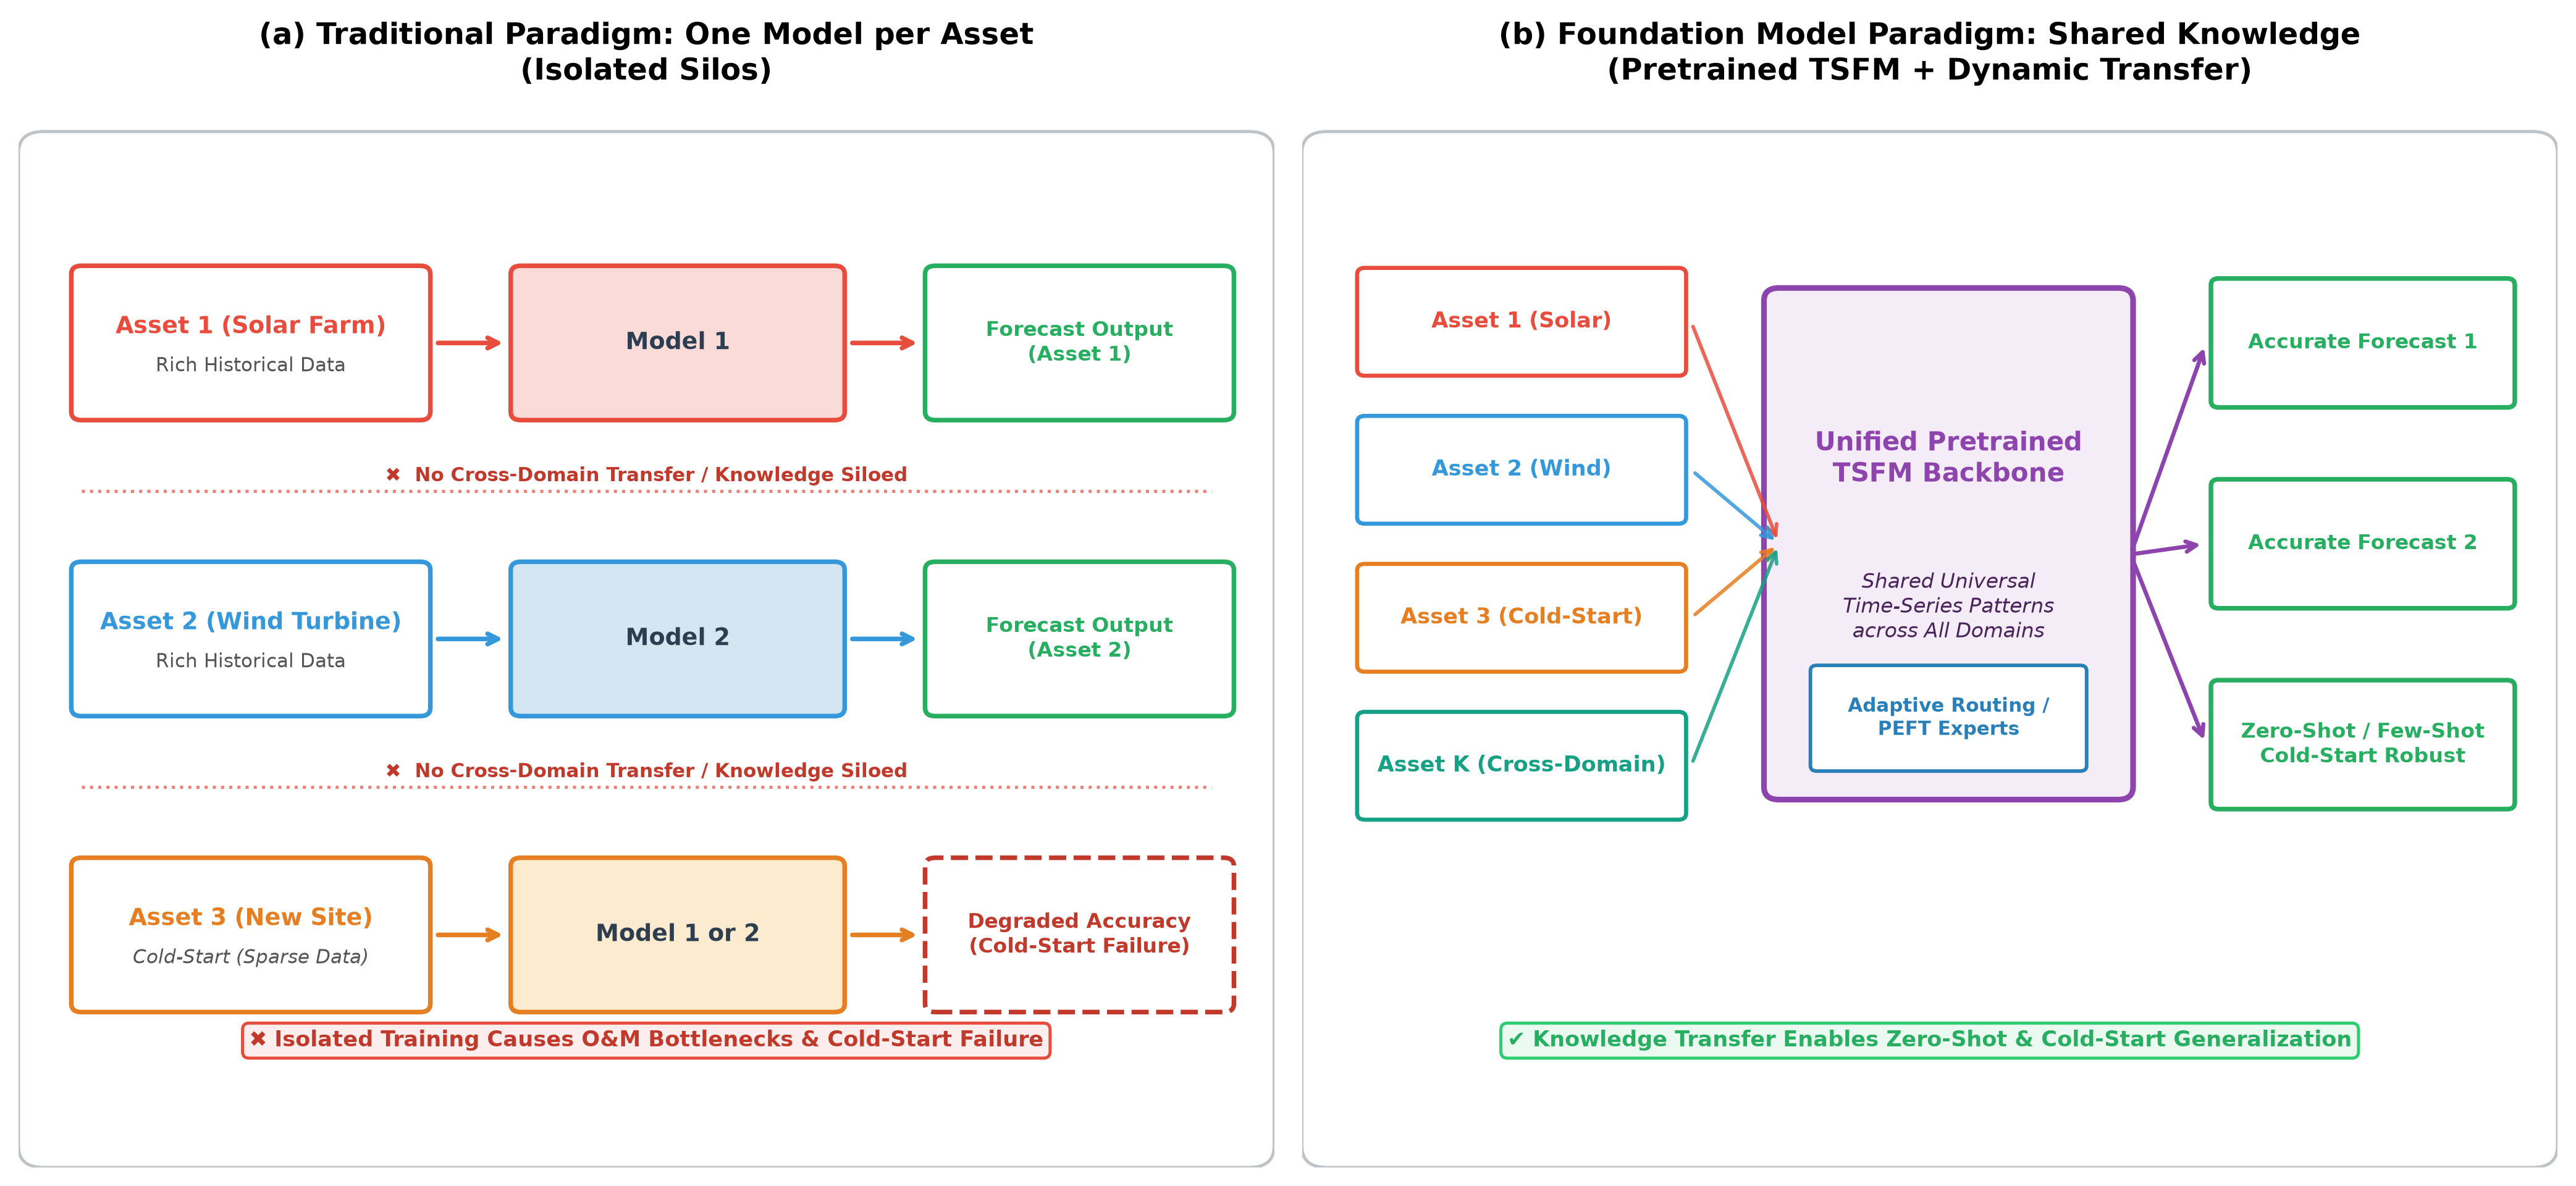

In [5]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

# 스타일 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), dpi=300)

# 색상 팔레트
c_asset1, c_asset2, c_asset3 = '#e74c3c', '#3498db', '#e67e22'
c_m1_bg, c_m2_bg, c_m3_bg = '#fadbd8', '#d4e6f1', '#fdebd0'
c_tsfm, c_tsfm_bg = '#8e44ad', '#f4ecf7'

# -------------------------------------------------------------------------
# Subplot 1: Traditional Paradigm (One Model per Asset)
# -------------------------------------------------------------------------
ax1.set_title(
    '(a) Traditional Paradigm: One Model per Asset\n(Isolated Silos)',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')

# 테두리 박스
ax1.add_patch(
    patches.FancyBboxPatch(
        (0.2, 0.2),
        9.6,
        9.4,
        boxstyle='round,pad=0.2',
        fc='#ffffff',
        ec='#bdc3c7',
        lw=1.2,
    )
)

assets_data = [
    (
        'Asset 1 (Solar Farm)',
        'Rich Historical Data',
        c_asset1,
        c_m1_bg,
        'Model 1',
        7.8,
        False,
    ),
    (
        'Asset 2 (Wind Turbine)',
        'Rich Historical Data',
        c_asset2,
        c_m2_bg,
        'Model 2',
        5.0,
        False,
    ),
    (
        'Asset 3 (New Site)',
        'Cold-Start (Sparse Data)',
        c_asset3,
        c_m3_bg,
        'Model 1 or 2',
        2.2,
        True,
    ),
]

for name, desc, stroke, fill, model_lbl, y, is_cold in assets_data:
  # Data Box
  ax1.add_patch(
      patches.FancyBboxPatch(
          (0.5, y - 0.65),
          2.7,
          1.3,
          boxstyle='round,pad=0.08',
          fc='#ffffff',
          ec=stroke,
          lw=1.8,
      )
  )
  ax1.text(
      1.85,
      y + 0.15,
      name,
      ha='center',
      va='center',
      fontsize=9,
      fontweight='bold',
      color=stroke,
  )
  ax1.text(
      1.85,
      y - 0.22,
      desc,
      ha='center',
      va='center',
      fontsize=7.5,
      color='#555555',
      fontstyle='italic' if is_cold else 'normal',
  )

  # Arrow 1
  ax1.annotate(
      '',
      xy=(3.9, y),
      xytext=(3.3, y),
      arrowprops=dict(arrowstyle='->', color=stroke, lw=1.8),
  )

  # Model Box
  ax1.add_patch(
      patches.FancyBboxPatch(
          (4.0, y - 0.65),
          2.5,
          1.3,
          boxstyle='round,pad=0.08',
          fc=fill,
          ec=stroke,
          lw=1.8,
      )
  )
  ax1.text(
      5.25,
      y,
      model_lbl,
      ha='center',
      va='center',
      fontsize=9,
      fontweight='bold',
      color='#2c3e50',
  )

  # Arrow 2
  ax1.annotate(
      '',
      xy=(7.2, y),
      xytext=(6.6, y),
      arrowprops=dict(arrowstyle='->', color=stroke, lw=1.8),
  )

  # Output Box
  out_txt = (
      'Degraded Accuracy\n(Cold-Start Failure)'
      if is_cold
      else f"Forecast Output\n({name.split()[0]} {name.split()[1]})"
  )
  out_col = '#c0392b' if is_cold else '#27ae60'
  ax1.add_patch(
      patches.FancyBboxPatch(
          (7.3, y - 0.65),
          2.3,
          1.3,
          boxstyle='round,pad=0.08',
          fc='#ffffff',
          ec=out_col,
          lw=1.8,
          ls='--' if is_cold else '-',
      )
  )
  ax1.text(
      8.45,
      y,
      out_txt,
      ha='center',
      va='center',
      fontsize=8,
      fontweight='bold',
      color=out_col,
  )

# 격리 장벽 (Barrier Line)
for y_line in [6.4, 3.6]:
  ax1.plot(
      [0.5, 9.5],
      [y_line, y_line],
      color='#e74c3c',
      linestyle=':',
      lw=1.2,
      alpha=0.7,
  )
  ax1.text(
      5.0,
      y_line + 0.14,
      '✖  No Cross-Domain Transfer / Knowledge Siloed',
      ha='center',
      va='center',
      fontsize=7.5,
      color='#c0392b',
      fontweight='bold',
  )

# -------------------------------------------------------------------------
# Subplot 2: Foundation Model Paradigm (Cross-Domain Transfer)
# -------------------------------------------------------------------------
ax2.set_title(
    '(b) Foundation Model Paradigm: Shared Knowledge\n(Pretrained TSFM +'
    ' Dynamic Transfer)',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')

ax2.add_patch(
    patches.FancyBboxPatch(
        (0.2, 0.2),
        9.6,
        9.4,
        boxstyle='round,pad=0.2',
        fc='#ffffff',
        ec='#bdc3c7',
        lw=1.2,
    )
)

multi_inputs = [
    ('Asset 1 (Solar)', 8.0, c_asset1),
    ('Asset 2 (Wind)', 6.6, c_asset2),
    ('Asset 3 (Cold-Start)', 5.2, c_asset3),
    ('Asset K (Cross-Domain)', 3.8, '#16a085'),
]

for name, y, stroke in multi_inputs:
  ax2.add_patch(
      patches.FancyBboxPatch(
          (0.5, y - 0.45),
          2.5,
          0.9,
          boxstyle='round,pad=0.06',
          fc='#ffffff',
          ec=stroke,
          lw=1.6,
      )
  )
  ax2.text(
      1.75,
      y,
      name,
      ha='center',
      va='center',
      fontsize=8.5,
      fontweight='bold',
      color=stroke,
  )
  ax2.annotate(
      '',
      xy=(3.8, 5.9),
      xytext=(3.1, y),
      arrowprops=dict(arrowstyle='->', color=stroke, lw=1.4, alpha=0.85),
  )

# TSFM Backbone Box
ax2.add_patch(
    patches.FancyBboxPatch(
        (3.8, 3.6),
        2.7,
        4.6,
        boxstyle='round,pad=0.12',
        fc=c_tsfm_bg,
        ec=c_tsfm,
        lw=2.2,
    )
)
ax2.text(
    5.15,
    6.7,
    'Unified Pretrained\nTSFM Backbone',
    ha='center',
    va='center',
    fontsize=10,
    fontweight='bold',
    color=c_tsfm,
)
ax2.text(
    5.15,
    5.3,
    'Shared Universal\nTime-Series Patterns\nacross All Domains',
    ha='center',
    va='center',
    fontsize=8,
    color='#4a235a',
    style='italic',
)

# Adapter Box
ax2.add_patch(
    patches.FancyBboxPatch(
        (4.1, 3.8),
        2.1,
        0.9,
        boxstyle='round,pad=0.05',
        fc='#ffffff',
        ec='#2980b9',
        lw=1.4,
    )
)
ax2.text(
    5.15,
    4.25,
    'Adaptive Routing /\nPEFT Experts',
    ha='center',
    va='center',
    fontsize=7.5,
    fontweight='bold',
    color='#2980b9',
)

# Output Arrows & Boxes
fm_outputs = [
    ('Accurate Forecast 1', 7.8, '#27ae60'),
    ('Accurate Forecast 2', 5.9, '#27ae60'),
    ('Zero-Shot / Few-Shot\nCold-Start Robust', 4.0, '#27ae60'),
]

for out_lbl, y, stroke in fm_outputs:
  ax2.annotate(
      '',
      xy=(7.2, y),
      xytext=(6.6, 5.8),
      arrowprops=dict(arrowstyle='->', color=c_tsfm, lw=1.6),
  )
  ax2.add_patch(
      patches.FancyBboxPatch(
          (7.3, y - 0.55),
          2.3,
          1.1,
          boxstyle='round,pad=0.06',
          fc='#ffffff',
          ec=stroke,
          lw=1.8,
      )
  )
  ax2.text(
      8.45,
      y,
      out_lbl,
      ha='center',
      va='center',
      fontsize=8,
      fontweight='bold',
      color=stroke,
  )

# 하단 메시지 배지
ax1.text(
    5.0,
    1.2,
    '✖ Isolated Training Causes O&M Bottlenecks & Cold-Start Failure',
    ha='center',
    va='center',
    fontsize=8.5,
    fontweight='bold',
    color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fdedec', ec='#e74c3c', lw=1.2),
)

ax2.text(
    5.0,
    1.2,
    '✔ Knowledge Transfer Enables Zero-Shot & Cold-Start Generalization',
    ha='center',
    va='center',
    fontsize=8.5,
    fontweight='bold',
    color='#27ae60',
    bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#2ecc71', lw=1.2),
)

plt.tight_layout()
plt.savefig('one_model_per_asset_figure.png', dpi=300, bbox_inches='tight')
plt.show()

findfont: Failed to find font weight semibold, now using 700.


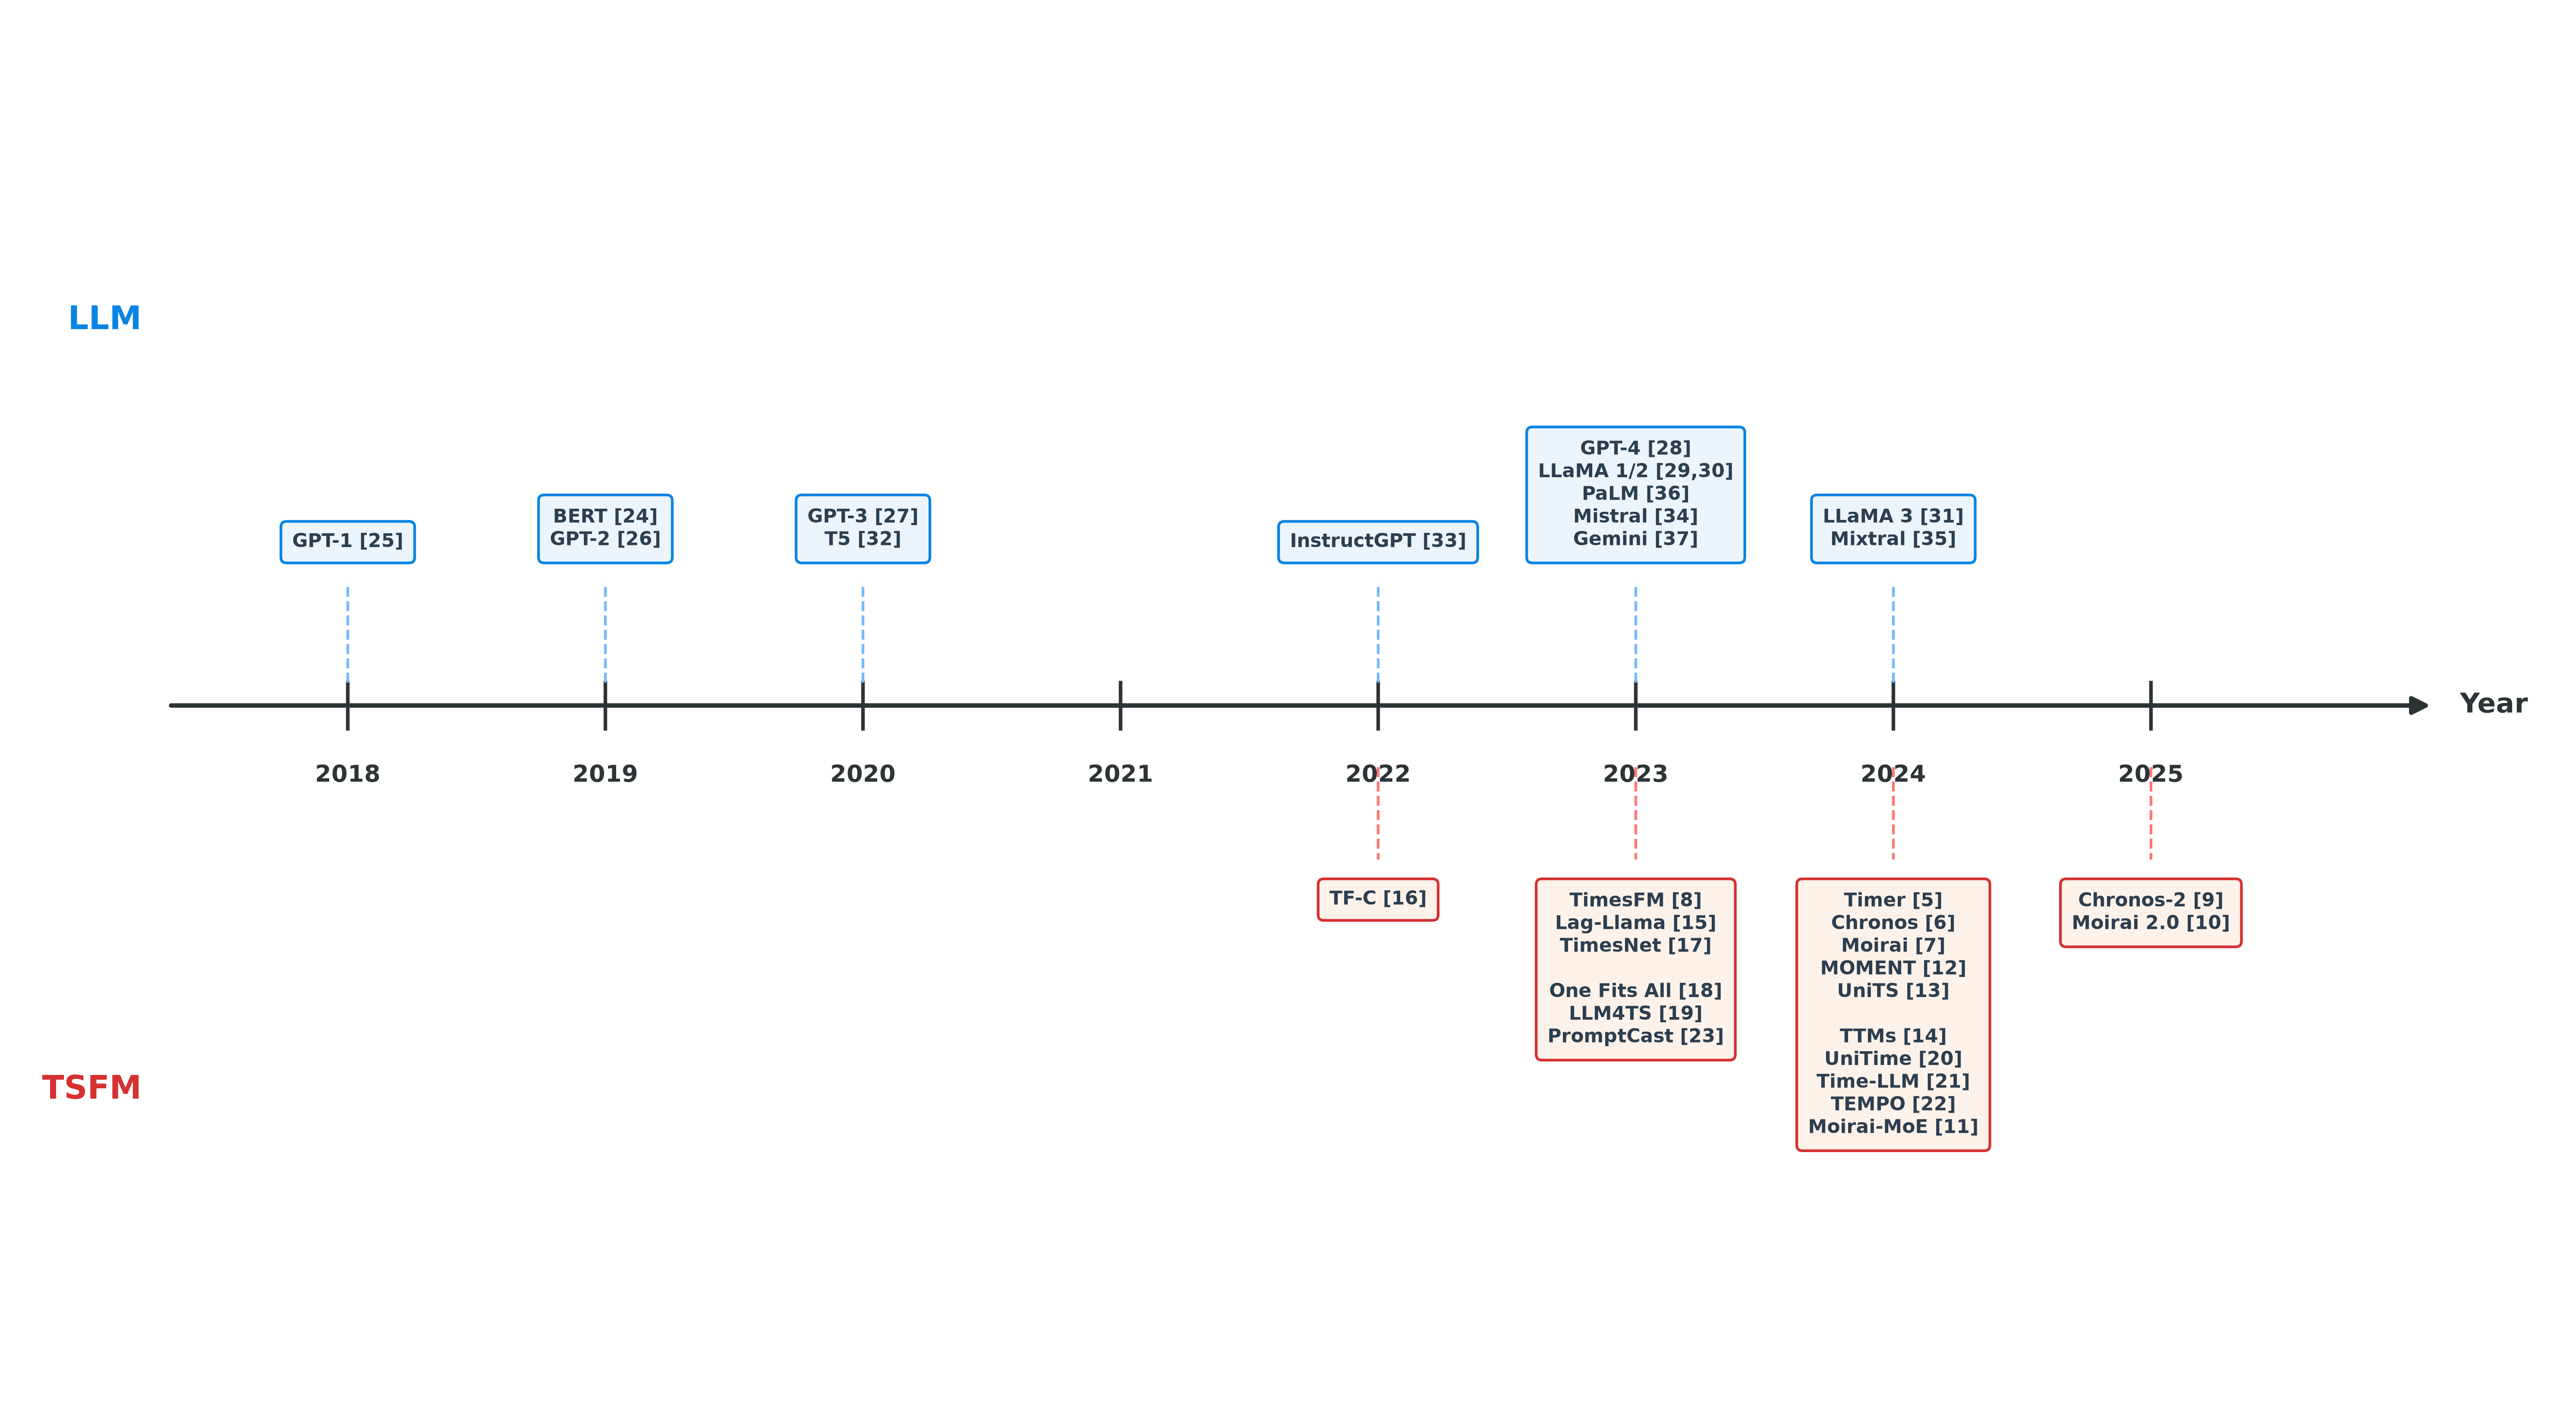

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 캔버스 및 스타일 설정
plt.figure(figsize=(20, 11), dpi=300, facecolor="white")
ax = plt.subplot(111)
ax.set_facecolor("white")

# 2. 데이터 정의 (연도별 매핑)
llm_data = {
    2018: ["GPT-1 [25]"],
    2019: ["BERT [24]", "GPT-2 [26]"],
    2020: ["GPT-3 [27]", "T5 [32]"],
    2022: ["InstructGPT [33]"],
    2023: ["GPT-4 [28]", "LLaMA 1/2 [29,30]", "PaLM [36]", "Mistral [34]", "Gemini [37]"],
    2024: ["LLaMA 3 [31]", "Mixtral [35]"],
}

tsfm_data = {
    2022: ["TF-C [16]"],
    2023: ["TimesFM [8]", "Lag-Llama [15]", "TimesNet [17]", "One Fits All [18]", "LLM4TS [19]", "PromptCast [23]"],
    2024: ["Timer [5]", "Chronos [6]", "Moirai [7]", "MOMENT [12]", "UniTS [13]", "TTMs [14]", "UniTime [20]", "Time-LLM [21]", "TEMPO [22]", "Moirai-MoE [11]"],
    2025: ["Chronos-2 [9]", "Moirai 2.0 [10]"],
}

years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
x_min, x_max = 2017.5, 2025.8

# 3. 중앙 연도 타임라인 축 (화살표)
ax.annotate(
    "",
    xy=(x_max + 0.3, 0),
    xytext=(x_min - 0.2, 0),
    arrowprops=dict(arrowstyle="-|>", color="#2d3436", lw=2.5, mutation_scale=20),
)
ax.text(x_max + 0.4, 0, "Year", va="center", ha="left", fontsize=15, fontweight="bold", color="#2d3436")

# 4. 좌측 레이블 (LLM / TSFM)
ax.text(x_min - 0.3, 2.5, "LLM", va="center", ha="right", fontsize=18, fontweight="bold", color="#0984e3")
ax.text(x_min - 0.3, -2.5, "TSFM", va="center", ha="right", fontsize=18, fontweight="bold", color="#d63031")

# 5. 연도 눈금 및 기준선 표시
for y in years:
    ax.plot([y, y], [-0.15, 0.15], color="#2d3436", lw=2)
    ax.text(y, 0, f"\n\n{y}", va="top", ha="center", fontsize=13, fontweight="bold", color="#2d3436")

# 6. 상단 LLM 박스 배치
for year, papers in llm_data.items():
    ax.plot([year, year], [0.15, 0.8], color="#74b9ff", lw=1.5, linestyle="--")
    # 텍스트 박스 병합 출력
    text_content = "\n".join(papers)
    ax.text(
        year,
        1.0,
        text_content,
        va="bottom",
        ha="center",
        fontsize=10.5,
        fontweight="semibold",
        color="#2c3e50",
        bbox=dict(boxstyle="round,pad=0.6,rounding_size=0.3", edgecolor="#0984e3", facecolor="#ebf5fb", lw=1.5),
    )

# 7. 하단 TSFM 박스 배치
for year, papers in tsfm_data.items():
    ax.plot([year, year], [-0.4, -1.0], color="#ff7675", lw=1.5, linestyle="--")
    
    # 논문 개수가 많은 2024년은 가독성을 위해 2열 배치 처리
    if len(papers) > 5:
        col1 = "\n".join(papers[:len(papers)//2])
        col2 = "\n".join(papers[len(papers)//2:])
        text_content = f"{col1}\n\n{col2}"
    else:
        text_content = "\n".join(papers)
        
    ax.text(
        year,
        -1.2,
        text_content,
        va="top",
        ha="center",
        fontsize=10.5,
        fontweight="semibold",
        color="#2c3e50",
        bbox=dict(boxstyle="round,pad=0.6,rounding_size=0.3", edgecolor="#d63031", facecolor="#fdf2e9", lw=1.5),
    )

# 8. 여백 및 축 가시성 제거
ax.set_xlim(x_min - 0.8, x_max + 0.8)
ax.set_ylim(-4.5, 4.5)
ax.axis("off")

plt.tight_layout()
plt.savefig("LLM_TSFM_Timeline.png", dpi=300, bbox_inches="tight")
plt.show()